<a href="https://colab.research.google.com/github/Taghreed-Alzahrani/-Naive-Bayes-/blob/main/AraBERT_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q transformers datasets arabert accelerate

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 185.0/185.0 kB 12.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 179.3/179.3 kB 17.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.4/126.4 kB 15.8 MB/s eta 0:00:00


In [ ]:
import os
import json
import shutil
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from google.colab import drive
from tqdm import tqdm

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    set_seed,
    EarlyStoppingCallback
)

from datasets import Dataset
from arabert.preprocess import ArabertPreprocessor

# تثبيت العشوائية
SEED = 42
set_seed(SEED)
np.random.seed(SEED)

In [ ]:
# ربط Google Drive
drive.mount('/content/drive')

# مسار ملف البيانات
file_path = "/content/drive/MyDrive/Project/synthetic_sensitivity_dataset_v3.csv"

# مجلد الحفظ الرئيسي
project_dir = "/content/drive/MyDrive/Project"

# مجلد خاص بتجربة AraBERT الجديدة بنفس تقسيم LLaMA
experiment_dir = os.path.join(project_dir, "arabert_same_llama_split")

# مجلد حفظ checkpoints
checkpoint_dir = os.path.join(experiment_dir, "checkpoints")

# مجلد حفظ  نموذج نهائي
final_model_dir = os.path.join(experiment_dir, "final_best_model")

# مجلد حفظ ملفات التقسيم
splits_dir = os.path.join(experiment_dir, "splits")

# إنشاء المجلدات
os.makedirs(experiment_dir, exist_ok=True)
os.makedirs(checkpoint_dir, exist_ok=True)
os.makedirs(final_model_dir, exist_ok=True)
os.makedirs(splits_dir, exist_ok=True)

print("Experiment directory:")
print(experiment_dir)

Mounted at /content/drive
Experiment directory:
/content/drive/MyDrive/Project/arabert_same_llama_split


In [ ]:
def save_checkpoint_to_drive(trainer, tokenizer, save_path, checkpoint_name="manual_checkpoint"):
    """
    دالة لحفظ checkpoint يدويًا على Google Drive.
    تحفظ:
    - أوزان النموذج
    - tokenizer
    - trainer state إذا متوفر
    """
    checkpoint_path = os.path.join(save_path, checkpoint_name)
    os.makedirs(checkpoint_path, exist_ok=True)

    trainer.save_model(checkpoint_path)
    tokenizer.save_pretrained(checkpoint_path)

    # حفظ حالة التدريب إن وجدت
    try:
        trainer.state.save_to_json(os.path.join(checkpoint_path, "trainer_state.json"))
    except Exception as e:
        print("لم يتم حفظ trainer_state.json:", e)

    print(f"تم حفظ checkpoint في: {checkpoint_path}")
    return checkpoint_path


def save_split_files(train_df, val_df, test_df, save_path):
    """
    دالة لحفظ تقسيم البيانات على Drive للتوثيق وإعادة الاستخدام.
    """
    os.makedirs(save_path, exist_ok=True)

    train_path = os.path.join(save_path, "train_split.csv")
    val_path = os.path.join(save_path, "validation_split.csv")
    test_path = os.path.join(save_path, "test_split.csv")

    train_df.to_csv(train_path, index=False, encoding="utf-8-sig")
    val_df.to_csv(val_path, index=False, encoding="utf-8-sig")
    test_df.to_csv(test_path, index=False, encoding="utf-8-sig")

    print("تم حفظ ملفات التقسيم:")
    print(train_path)
    print(val_path)
    print(test_path)


def save_text_results(results_text, save_path, file_name="arabert_test_results.txt"):
    """
    دالة لحفظ النتائج النصية في ملف.
    """
    os.makedirs(save_path, exist_ok=True)
    results_path = os.path.join(save_path, file_name)

    with open(results_path, "w", encoding="utf-8") as f:
        f.write(results_text)

    print(f"تم حفظ النتائج في: {results_path}")
    return results_path

In [ ]:
# قراءة البيانات
df = pd.read_csv(file_path, encoding="utf-8")

# إعادة تسمية الأعمدة لتناسب AraBERT
df = df.rename(columns={
    "content": "text",
    "sensitivity_level": "label"
})

# حذف الصفوف الفارغة
df = df.dropna(subset=["text", "label"])

# التأكد من نوع البيانات
df["text"] = df["text"].astype(str)
df["label"] = df["label"].astype(str).str.strip()

print("عدد السجلات بعد التنظيف الأولي:", len(df))

print("\nتوزيع الفئات قبل التحويل:")
print(df["label"].value_counts())

عدد السجلات بعد التنظيف الأولي: 40000

توزيع الفئات قبل التحويل:
label
سري للغاية    10000
سري           10000
مقيد          10000
عام           10000
Name: count, dtype: int64


In [ ]:
tqdm.pandas()

model_name = "aubmindlab/bert-base-arabertv02"

arabert_prep = ArabertPreprocessor(model_name=model_name)

print("جاري تطبيق AraBERT preprocessing...")

df["text"] = df["text"].progress_apply(arabert_prep.preprocess)

print("\nتمت المعالجة.")
print(df.head())

جاري تطبيق AraBERT preprocessing...


100%|██████████| 40000/40000 [00:10<00:00, 3813.15it/s]



تمت المعالجة.
                                                text       label
0  صياغة سيناريوهات تشغيل موجه إلى الجهات ذات الع...  سري للغاية
1  جرى تدقيق نقاط التحسين مع توثيق النتائج وفق ال...  سري للغاية
2  مراجعة أسباب التباين موجه إلى المعنيين بصيغة ر...         سري
3  بالإشارة إلى المستجدات ، نوضح ما يلي ضمن إدارة...        مقيد
4  أدرجت الملاحظات ذات العلاقة في ملخص المرحلة با...        مقيد


In [ ]:
# ==========================================
# Train / Validation / Test Split
# Same as LLaMA: 70 / 15 / 15
# ==========================================

# المرحلة الأولى:
# 70% تدريب
# 30% مؤقتة
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df["label"],
    random_state=SEED
)

# المرحلة الثانية:
# تقسيم الـ 30% المؤقتة بالنصف
# 15% تحقق
# 15% اختبار
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=SEED
)

print("Final Split Sizes:")
print(f"Training:   {len(train_df)} records ({len(train_df) / len(df) * 100:.2f}%)")
print(f"Validation: {len(val_df)} records ({len(val_df) / len(df) * 100:.2f}%)")
print(f"Test:       {len(test_df)} records ({len(test_df) / len(df) * 100:.2f}%)")

print("\nTraining class distribution:")
print(train_df["label"].value_counts().sort_index())

print("\nValidation class distribution:")
print(val_df["label"].value_counts().sort_index())

print("\nTest class distribution:")
print(test_df["label"].value_counts().sort_index())

# حفظ ملفات التقسيم للتوثيق
save_split_files(train_df, val_df, test_df, splits_dir)

Final Split Sizes:
Training:   28000 records (70.00%)
Validation: 6000 records (15.00%)
Test:       6000 records (15.00%)

Training class distribution:
label
سري           7000
سري للغاية    7000
عام           7000
مقيد          7000
Name: count, dtype: int64

Validation class distribution:
label
سري           1500
سري للغاية    1500
عام           1500
مقيد          1500
Name: count, dtype: int64

Test class distribution:
label
سري           1500
سري للغاية    1500
عام           1500
مقيد          1500
Name: count, dtype: int64
تم حفظ ملفات التقسيم:
/content/drive/MyDrive/Project/arabert_same_llama_split/splits/train_split.csv
/content/drive/MyDrive/Project/arabert_same_llama_split/splits/validation_split.csv
/content/drive/MyDrive/Project/arabert_same_llama_split/splits/test_split.csv


In [ ]:
tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize_function(examples):
    return tokenizer(
        examples["text"],
        padding="max_length",
        truncation=True,
        max_length=512
    )

# تحويل DataFrame إلى Hugging Face Dataset
train_dataset = Dataset.from_pandas(train_df[["text", "label"]], preserve_index=False)
val_dataset = Dataset.from_pandas(val_df[["text", "label"]], preserve_index=False)
test_dataset = Dataset.from_pandas(test_df[["text", "label"]], preserve_index=False)

# تطبيق tokenization
train_dataset = train_dataset.map(tokenize_function, batched=True)
val_dataset = val_dataset.map(tokenize_function, batched=True)
test_dataset = test_dataset.map(tokenize_function, batched=True)

# Map string labels to integer IDs
train_dataset = train_dataset.map(lambda x: {"label": label2id[x["label"]]})
val_dataset = val_dataset.map(lambda x: {"label": label2id[x["label"]]})
test_dataset = test_dataset.map(lambda x: {"label": label2id[x["label"]]})

# حذف النص الخام بعد التحويل
train_dataset = train_dataset.remove_columns(["text"])
val_dataset = val_dataset.remove_columns(["text"])
test_dataset = test_dataset.remove_columns(["text"])

# تجهيز البيانات لـ PyTorch
train_dataset.set_format("torch", columns=["input_ids", "attention_mask", "label"])
val_dataset.set_format("torch", columns=["input_ids", "attention_mask", "label"])
test_dataset.set_format("torch", columns=["input_ids", "attention_mask", "label"])

print("Datasets are ready.")

Map:   0%|          | 0/28000 [00:00<?, ? examples/s]

Map:   0%|          | 0/6000 [00:00<?, ? examples/s]

Map:   0%|          | 0/6000 [00:00<?, ? examples/s]

Map:   0%|          | 0/28000 [00:00<?, ? examples/s]

Map:   0%|          | 0/6000 [00:00<?, ? examples/s]

Map:   0%|          | 0/6000 [00:00<?, ? examples/s]

Datasets are ready.


In [ ]:
unique_labels = df["label"].unique()
label2id = {label: i for i, label in enumerate(sorted(unique_labels))}
id2label = {i: label for label, i in label2id.items()}

model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=4,
    id2label=id2label,
    label2id=label2id,
    hidden_dropout_prob=0.1
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: aubmindlab/bert-base-arabertv02
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Conside

In [ ]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    accuracy = accuracy_score(labels, predictions)
    macro_f1 = f1_score(labels, predictions, average="macro")

    return {
        "accuracy": accuracy,
        "macro_f1": macro_f1
    }

In [ ]:
training_args = TrainingArguments(
    output_dir=checkpoint_dir,

    # Evaluation and saving
    eval_strategy="steps",
    eval_steps=500,
    save_strategy="steps",
    save_steps=500,
    logging_strategy="steps",
    logging_steps=500,

    # Training settings
    learning_rate=3e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=2,
    weight_decay=0.01,

    # Best model selection
    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    greater_is_better=True,

    # Keep limited checkpoints
    save_total_limit=2,

    # Reproducibility
    seed=SEED,

    # Disable external logging
    report_to="none"
)

In [ ]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    callbacks=[
        EarlyStoppingCallback(early_stopping_patience=2)
    ]
)

print("start training.")
train_result = trainer.train()

print("\n done.")
print(train_result)

start training.


Step,Training Loss,Validation Loss,Accuracy,Macro F1
500,0.625645,0.507816,0.720667,0.738025
1000,0.500922,0.500922,0.745833,0.762669
1500,0.486726,0.500790,0.745833,0.762669
2000,0.501630,0.501666,0.745833,0.762669


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La


 done.
TrainOutput(global_step=2000, training_loss=0.5287308731079101, metrics={'train_runtime': 1609.0982, 'train_samples_per_second': 34.802, 'train_steps_per_second': 2.175, 'total_flos': 8419704963072000.0, 'train_loss': 0.5287308731079101, 'epoch': 1.1428571428571428})


In [ ]:
print("loading...")

trainer.save_model(final_model_dir)
tokenizer.save_pretrained(final_model_dir)

# حفظ حالة التدريب
trainer.state.save_to_json(os.path.join(final_model_dir, "trainer_state.json"))

print(" model saved:")
print(final_model_dir)

loading...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

 model saved:
/content/drive/MyDrive/Project/arabert_same_llama_split/final_best_model


In [ ]:
manual_checkpoint_path = save_checkpoint_to_drive(
    trainer=trainer,
    tokenizer=tokenizer,
    save_path=experiment_dir,
    checkpoint_name="manual_final_checkpoint"
)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

تم حفظ checkpoint في: /content/drive/MyDrive/Project/arabert_same_llama_split/manual_final_checkpoint


In [ ]:
print("--- Final Evaluation on Test Set ---")

test_predictions = trainer.predict(test_dataset)

y_pred = np.argmax(test_predictions.predictions, axis=-1)
y_true = test_predictions.label_ids

accuracy = accuracy_score(y_true, y_pred)
macro_f1 = f1_score(y_true, y_pred, average="macro")

class_names = ["عام", "مقيد", "سري", "سري للغاية"]

print(f"Accuracy: {accuracy:.4f}")
print(f"Macro F1: {macro_f1:.4f}")

print("\nClassification Report:")
report = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    digits=4
)


print("\u200e" + report)

--- Final Evaluation on Test Set ---


Accuracy: 0.7450
Macro F1: 0.7619

Classification Report:
‎              precision    recall  f1-score   support

         عام     1.0000    0.6660    0.7995      1500
        مقيد     1.0000    0.6587    0.7942      1500
         سري     0.4950    1.0000    0.6623      1500
  سري للغاية     1.0000    0.6553    0.7918      1500

    accuracy                         0.7450      6000
   macro avg     0.8738    0.7450    0.7619      6000
weighted avg     0.8738    0.7450    0.7619      6000



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 299.6/299.6 kB 23.5 MB/s eta 0:00:00


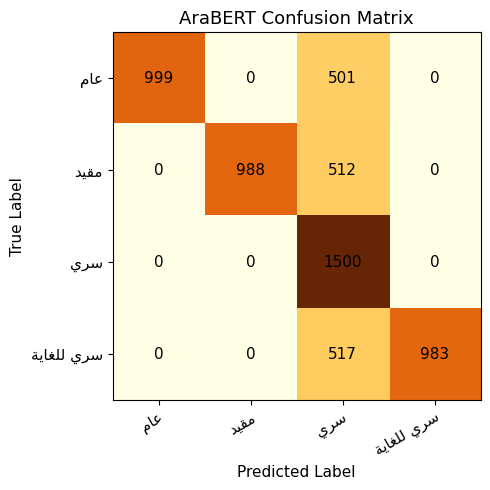

In [ ]:
!pip install -q arabic-reshaper python-bidi
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import arabic_reshaper
from bidi.algorithm import get_display
import numpy as np

# حساب مصفوفة الارتباك
cm = confusion_matrix(y_true, y_pred)

# أسماء الفئات الأصلية
class_names = ["عام", "مقيد", "سري", "سري للغاية"]

def fix_arabic_text(text):
    reshaped_text = arabic_reshaper.reshape(text)
    bidi_text = get_display(reshaped_text)
    return bidi_text

# تطبيق التصحيح على أسماء الفئات
fixed_class_names = [fix_arabic_text(label) for label in class_names]

fig, ax = plt.subplots(figsize=(6, 5))

im = ax.imshow(cm, cmap="YlOrBr")

# وضع أسماء المحاور
ax.set_xticks(np.arange(len(fixed_class_names)))
ax.set_yticks(np.arange(len(fixed_class_names)))

ax.set_xticklabels(fixed_class_names, fontsize=11)
ax.set_yticklabels(fixed_class_names, fontsize=11)

plt.setp(ax.get_xticklabels(), rotation=30, ha="right", rotation_mode="anchor")

# كتابة الأرقام داخل الخلايا
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center",
            fontsize=11
        )

ax.set_title("AraBERT Confusion Matrix", fontsize=13)
ax.set_xlabel("Predicted Label", fontsize=11)
ax.set_ylabel("True Label", fontsize=11)



plt.tight_layout()
plt.show()

In [ ]:
results_text = f"""
AraBERT Final Test Results
==========================

Split Setting:
Training   = 70%
Validation = 15%
Test       = 15%

Training size:   {len(train_df)}
Validation size: {len(val_df)}
Test size:       {len(test_df)}

Training Settings:
Model: {model_name}
Epochs: 2
Batch size: 16
Max length: 512
Learning rate: 3e-5
Evaluation metric for best checkpoint: Macro F1

Final Test Results:
Accuracy: {accuracy:.4f}
Macro F1: {macro_f1:.4f}

Classification Report:
{report}

Confusion Matrix:
{cm}
"""

save_text_results(
    results_text=results_text,
    save_path=experiment_dir,
    file_name="arabert_same_llama_split_test_results.txt"
)

تم حفظ النتائج في: /content/drive/MyDrive/Project/arabert_same_llama_split/arabert_same_llama_split_test_results.txt


'/content/drive/MyDrive/Project/arabert_same_llama_split/arabert_same_llama_split_test_results.txt'